In [10]:
# import modules
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from gmachine.freq_data import AtomInterferometerModel
from dataclasses import replace
import gmachine as gm
from scipy.optimize import curve_fit
import json
import os
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import loadmat

from gmachine.freq_data import PhaseNoise
from gmachine.time_data import TimeSeries

In [11]:
# create this function to get access to the full data (not only the phase)
def load_timeseries_from_signalhound_iq_phasor(
    filename: os.PathLike[str], name: str = "") -> TimeSeries:
    """
    Load a timeseries from a Signalhound IQ data file. Assumes time is in seconds.
    """
    # FIXME: Use pathlib instead of os
    #  Read metadata from xml file
    tree = ET.parse(os.path.splitext(filename)[0] + ".xml")
    scale_factor = float(tree.find("ScaleFactor").text)  # type: ignore[arg-type, union-attr] # noqa: E501
    sample_rate = float(tree.find("SampleRate").text)  # type: ignore[arg-type, union-attr] # noqa: E501
    # center_freq = float(tree.find("CenterFrequency").text)

    with open(filename, "rb") as f:
        # Read the data into a NumPy array
        array = np.fromfile(f, dtype=np.short)  # Change dtype according to your data
    sI = array[0::2] / 2**15 / scale_factor
    sQ = array[1::2] / 2**15 / scale_factor
    
    return TimeSeries(sI + 1j * sQ, sample_rate, name=name, unit="")

In [12]:
#path directory to your iq files
pathDirectory = Path("Beat note/")
pathDirectory.exists()

True

In [13]:
# data self heterodyning
name_iq_data = "IDEFIX_SelfHetero-09-15-25-14h30m19s331"   # file name of your iq file

namefile_iq_data = name_iq_data+".iq"

iq_data_laser = gm.io.load_timeseries_from_signalhound_iq(
pathDirectory
    / namefile_iq_data,
    name="iq_data",
)

# subtract linear drift of signal hound
#iq_data_laser = gm.time_data.detrend(iq_data_laser, type="linear")

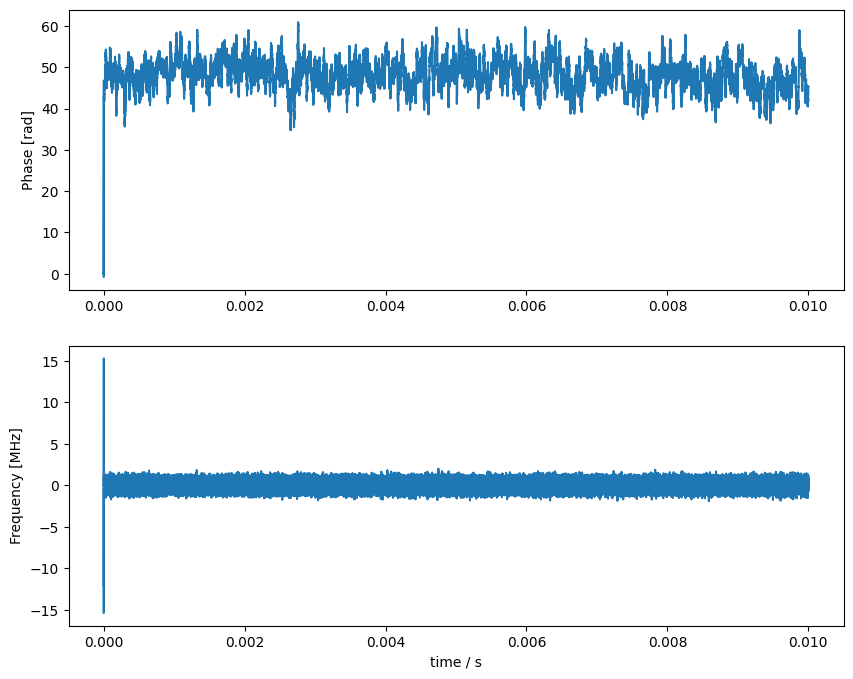

In [14]:
# extract phase and frequency from iq data
detrended_phase_laser = iq_data_laser.values 
frequency_laser = np.diff(detrended_phase_laser)* iq_data_laser.sample_rate/(2*np.pi) 
time_laser = np.arange(len(iq_data_laser)) / iq_data_laser.sample_rate

plot = 1

#plot the timeseries
if plot:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    ax1.plot(time_laser, detrended_phase_laser)
    ax1.set_ylabel("Phase [rad]")
    ax2.plot(time_laser[:-1], frequency_laser * 1e-6)  # time[:-1] because np.diff reduces the length by 1
    ax2.set_ylabel("Frequency [MHz]")
    ax2.set_xlabel("time / s")

Laser linewidth at 1 kHz: 126.91 kHz


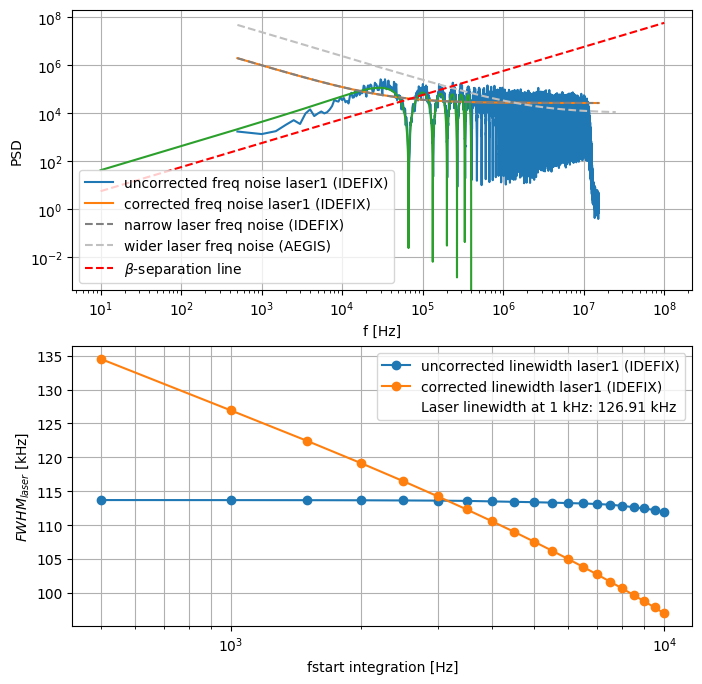

In [29]:
# Power spectral density using Welch method 
from scipy.signal import welch
import sympy as sp

# Load other laser data for comparison
with np.load("baselines.npz") as data:
    x_IDEFIX         = data["x_IDEFIX"]
    x_AEGIS          = data["x_AEGIS"]
    baseline_IDEFIX  = data["baseline_IDEFIX"]
    baseline_AEGIS   = data["baseline_AEGIS"]

# Calculate the frequency noise spectrum
def calc_freq_noise_spectrum(fs_laser, iq_data):
    frequencies_laser, S_f_welch_laser = welch(fs_laser, fs=iq_data_laser.sample_rate,nperseg=len(iq_data_laser)/5)
    frequencies_laser, S_f_welch_laser = frequencies_laser[1:], S_f_welch_laser[1:]
    return frequencies_laser, S_f_welch_laser

frequencies_laser, S_f_welch_laser = calc_freq_noise_spectrum(frequency_laser, iq_data_laser)
    


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))


# Fit the uncorretcted data and the white noise floor, delay path length and pink noise as inputs
def fit_freq_noise(frequencies_laser, S_f_welch_laser,
                   c_noise, delay_length, pink_noise):
    
    def mod_fit(x, a):
        return (a / x + c_noise) * (1 - np.cos(2 * np.pi * tau * x))

    params_laser, covariance_laser = curve_fit(
        mod_fit, frequencies_laser, S_f_welch_laser,
        p0=[float(pink_noise)],
        bounds=(0, np.inf),
        maxfev=10_000_000
    )

    errors = np.sqrt(np.diag(covariance_laser))

    freq_space = np.linspace(10, 400_000, 10_000)
    welch_fit_laser = mod_fit(freq_space, *params_laser)

    return freq_space, welch_fit_laser, params_laser, errors

freq_space, welch_fit_laser, params_laser, errors = fit_freq_noise(
    frequencies_laser, S_f_welch_laser,
    c_noise=2.6e4,
    delay_length=3_000,
    pink_noise=2e10
)


# Calculation of the corrected frequency noise
def calc_corrected_freq_noise_spectrum(mod_fit_parameter, frequencies_laser, c_noise):
    corrected_welch_laser = mod_fit_parameter[0]/frequencies_laser + c_noise
    return corrected_welch_laser

corrected_welch_laser = calc_corrected_freq_noise_spectrum(params_laser, frequencies_laser, 2.6e4)


# Calculation of the laser linewidth requires the minimum amd maximum start frequency of the integration, the nu,ber of start frequencies and the beta seperation line intersection  
def calc_laser_linewidth(frequencies_laser, S_f_welch_laser, corrected_welch_laser, fstart_min, fstart_max, fstart_len, beta_freq):
    linewidth_corrected_laser = []
    linewidth_laser = []
    linewidth_kHz = ""
    fstart = np.linspace(fstart_min, fstart_max, fstart_len)
    # Integartion of frequecy noise between min and max frequency
    for freq_min in fstart:
        indices_laser = np.logical_and(frequencies_laser >= freq_min, frequencies_laser <= beta_freq)
        A_corrected_laser = np.trapz(corrected_welch_laser[indices_laser], frequencies_laser[indices_laser])
        A_laser = np.trapz(S_f_welch_laser[indices_laser], frequencies_laser[indices_laser])
        linewidth_laser.append(np.sqrt(A_laser*8*np.log(2))*1e-3)
        linewidth_corrected_laser.append(np.sqrt(A_corrected_laser*8*np.log(2))*1e-3)
        if freq_min == 1000.0:
            linewidth_kHz = (f"Laser linewidth at 1 kHz: {round(linewidth_corrected_laser[-1]/np.sqrt(2), 2)} kHz")  
            print(linewidth_kHz)
    return linewidth_laser, linewidth_corrected_laser, linewidth_kHz, fstart

linewidth_laser, linewidth_corrected_laser, linewidth_kHz, fstart = calc_laser_linewidth(frequencies_laser, S_f_welch_laser, corrected_welch_laser, 5e2, 1e4, 20, 7e4)

# plot the Power spectral density
if plot==1:

    ax1.plot(frequencies_laser, S_f_welch_laser,'-', label="uncorrected freq noise laser1 (IDEFIX)")  # plot uncorretced freq noise
    ax1.plot(frequencies_laser, corrected_welch_laser, label="corrected freq noise laser1 (IDEFIX)")  # plot corrected freq noise
    ax1.plot(freq_space, welch_fit_laser)  # plot fit function
    ax1.plot(x_IDEFIX, baseline_IDEFIX, label="narrow laser freq noise (IDEFIX)", color="grey", linestyle="--")  # Comparison with a narrow laser
    ax1.plot(x_AEGIS,  baseline_AEGIS,  label="wider laser freq noise (AEGIS)", color="silver", linestyle="--")  # Comparison with a wider laser
    ax1.set_xlabel("f [Hz]")
    ax1.set_ylabel("PSD")
    ax1.set_xscale("log")
    ax1.set_yscale("log")

    
    # plot the linewidth for different integration start frequencies
    f_linspace = np.linspace(10,1e8,1000)
    ax1.plot(f_linspace, f_linspace*8*np.log(2)/np.pi**2,'--r',label=r'$\beta$-separation line')
    ax2.plot(fstart,linewidth_laser/np.sqrt(2),'o-',label="uncorrected linewidth laser1 (IDEFIX)")
    ax2.plot(fstart,linewidth_corrected_laser/np.sqrt(2),'o-',label="corrected linewidth laser1 (IDEFIX)")
    ax2.plot([], [], color="none", label=linewidth_kHz)
    ax2.set_xlabel("fstart integration [Hz]"); ax2.set_ylabel(r"$FWHM_{laser}$ [kHz]")
    ax2.set_xscale("log") ; # ax2.set_xscale("log")
    ax2.legend()
    ax2.grid(which="minor")
    ax2.grid(which="major")

    ax1.legend()
    ax1.grid()
